In [18]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from dataset import WaveletDataset
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt 
from Model.MENDR.mAtt.optimizer import MixOptimizer
import random
import os
import math
from dataset import WaveletFinetuningDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
train_frac = 0.2
val_frac = 0.001
dataset = WaveletDataset(root="/home/hice1/mchen439/scratch/eegfoundationmodeldata", frac=train_frac + val_frac)
num_train = int(len(dataset) * (train_frac / (train_frac + val_frac)))
num_val = len(dataset) - num_train
train_dataset, val_dataset = torchdata.random_split(dataset, [num_train, num_val])
print("Train and Validation Dataset Length: ", len(train_dataset), len(val_dataset))

Loading 2651 subjects


100%|██████████| 2651/2651 [01:07<00:00, 39.32it/s]


Train and Validation Dataset Length:  25436 128


In [3]:
### Seed ###
torch.cuda.empty_cache()
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
## CUDNN ##
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


In [4]:
train_loader = DataLoader(train_dataset, batch_size=128, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, num_workers=2, shuffle=False)
print(len(train_loader), len(val_loader))

199 1


In [5]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

In [6]:
class WaveletEncoderDecoder(nn.Module):
    def __init__(self, num_channels, patch_size, heads, seq_len, encoded_h, device):
        super(WaveletEncoderDecoder, self).__init__()
        self.num_channels = num_channels
        self.channel_dropout = nn.Dropout1d(0.1)
        self.patch_size = patch_size
        self.stride = self.patch_size // 2
        self.device = device
        self.heads = heads
        self.encoded_h = encoded_h
        self.seq_len = seq_len

        self.act = nn.GELU()
        L_out = self.seq_len + 2 * (0) - 1 * (self.patch_size - 1) - 1
        L_out = floor(L_out / self.patch_size) + 1

        self.patch_embedder1 = nn.Sequential(
            nn.Conv1d(in_channels=self.num_channels, out_channels=self.num_channels, kernel_size=self.patch_size, stride=self.patch_size),
        ).to(self.device)

        #self.gnn_channel_encoder = SplineConv(L_out, self.seq_len, dim=1, kernel_size=3).to(self.device)
        self.gnn_channel_encoder = GATConv(L_out, self.seq_len, heads=self.heads, concat=False).to(self.device)

        L_out = self.seq_len + 2 * (0) - 1 * (self.patch_size - 1) - 1
        L_out = floor(L_out / self.stride) + 1

        self.patch_embedder2 = nn.Sequential(
            # 101 is what they used in BIOT
            nn.Conv1d(in_channels=1, out_channels=101, kernel_size=self.patch_size, stride=self.stride),
        ).to(self.device)
        self.patch_embedder_lin = nn.Sequential(self.act, nn.Linear(101, encoded_h))

        self.learnable_mask = torch.nn.Parameter(torch.randn(self.encoded_h, requires_grad=True))
        self.transformer_decoder1 = nn.TransformerDecoderLayer(self.encoded_h, nhead=2, dim_feedforward=self.encoded_h, activation=nn.GELU(), batch_first=True).to(self.device)
        self.transformer_decoder2 = nn.TransformerDecoderLayer(self.encoded_h, nhead=2, dim_feedforward=self.encoded_h, activation=nn.GELU(), batch_first=True).to(self.device)
        self.decoder3 = nn.ConvTranspose1d(in_channels=encoded_h, out_channels=self.num_channels, kernel_size=19, stride=1)
        L_out = (self.num_channels*L_out) * 1 - 2 * 0 + 1 * (19 - 1) + 0
        self.decoder4 = nn.Sequential(nn.Linear(L_out, L_out), self.act)
        self.decoder5 = nn.Linear(L_out, seq_len)
    def getEncoderParamCount(self):
        gnn_encoder_count = sum(p.numel() for p in self.gnn_encoder.parameters() if p.requires_grad)
        return gnn_encoder_count

    def getDecoderParamCount(self):
        transformer_decoder1_count = sum(p.numel() for p in self.transformer_decoder1.parameters() if p.requires_grad)
        transformer_decoder2_count = sum(p.numel() for p in self.transformer_decoder1.parameters() if p.requires_grad)
        return transformer_decoder1_count + transformer_decoder2_count

    def forward(self, graph, x):
        # x: [Batch Size, Channels, Time Steps]
        emb_seq = []
        x = self.channel_dropout(x)

        x_ch = self.patch_embedder1(x)
        edge_index = graph.edge_index.to(self.device)
        edge_dist = graph.edge_attr.to(self.device)
        gnn_channel_encoder_input = x_ch.view(-1, x_ch.shape[-1])
        channel_encoding = self.gnn_channel_encoder(gnn_channel_encoder_input, edge_index, edge_dist)
        x = x + channel_encoding.view(x.shape[0], -1, channel_encoding.shape[-1])
        for i in range(x.shape[1]):
            channelwise_patch = x[:, i:i+1, :]
            patch_embedding = self.patch_embedder2(channelwise_patch)
            patch_embedding = patch_embedding.permute(0, 2, 1)
            patch_embedding = self.patch_embedder_lin(patch_embedding)
            emb_seq.append(patch_embedding)

        # emb_seq: [Batch Size, 19 * L_out, patch_size]
        emb_seq = torch.cat(emb_seq, dim=1)

        masked_emb_seq = emb_seq.clone()
        for batch_idx in range(masked_emb_seq.shape[0]):
            mask_indices = torch.randperm(emb_seq.shape[1])[:int(emb_seq.shape[1] * .1)]
            for mask_idx in mask_indices:
                masked_emb_seq[batch_idx, mask_idx, :] = self.learnable_mask

        decoding_tgt = masked_emb_seq.to(self.device)
        decoding = self.transformer_decoder1(tgt=decoding_tgt, memory=masked_emb_seq)
        # Skip Connnection
        decoding = decoding + decoding_tgt
        decoding_skip = self.transformer_decoder2(tgt=decoding, memory=masked_emb_seq)
        # Skip Connnection
        decoding = decoding_skip + decoding
        decoding = decoding.permute(0, 2, 1)
        decoding = self.decoder3(decoding)
        # Skip Connection
        decoding = decoding + self.decoder4(decoding) 
        decoding = self.decoder5(decoding) 
        return emb_seq, decoding


'''
Initialize Encoders for each wavelet band and 
put them into a single object.
'''
class EncoderDecoder(nn.Module):
    def __init__(self, device):
        super(EncoderDecoder, self).__init__()
        self.device = device
        self.encoder_decoders = nn.ParameterDict({
            'delta': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=41,
                    encoded_h=16,
                    heads=1,
                    seq_len=246,
                    device = device
                    ),

            'theta': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=41,
                    encoded_h=16,
                    heads=1,
                    seq_len=246,
                    device = device
                    ),
            'alpha': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=81,
                    encoded_h=32,
                    heads=1,
                    seq_len=486,
                    device = device 
                    ),

            'beta': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=161,
                    encoded_h=64,
                    heads=1,
                    seq_len = 966,
                    device = device
                    ),

            'gamma': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size = 320,
                    encoded_h = 128,
                    heads=1,
                    seq_len=1925,
                    device = device
                    ),
        })

    def forward(self, graph, data):
        assert data.keys() == self.encoder_decoders.keys()
        output = {}
        for band, band_decomposition in data.items():
            output[band] = self.encoder_decoders[band](graph, band_decomposition)
        return output

    def freeze_features(self, unfreeze=False, finetuning=False):
        for param in self.parameters():
            param.requires_grad = unfreeze
        if finetuning:
            self.mask_replacement.requires_grad = False

In [7]:
def _std_norm(x):
	mean = torch.mean(x, dim=(0, 1), keepdim=True)
	std = torch.std(x, dim=(0, 1), keepdim=True)
	x = (x - mean) / std
	return x

In [8]:
model = EncoderDecoder(device).to(device)
optimizer = MixOptimizer(torch.optim.Adam(model.parameters(), lr=1e-3))
loss_fn = nn.MSELoss()
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Total parameters: 2041252


In [9]:
#model.encoder_decoders['delta'](None, torch.randn(4, 19, 246).to(device))

In [10]:
def fft_loss(output, target):
    output_fft = torch.fft.fft(output, dim=-1)
    output_amplitude = torch.abs(output_fft)
    output_angle = torch.angle(output_fft)

    target_fft = torch.fft.fft(target, dim=-1)
    target_amplitude = torch.abs(target_fft)
    target_angle = torch.abs(target_fft)

    return (loss_fn(output_amplitude, target_amplitude) + (loss_fn(output_angle, target_angle)))

In [11]:
def calculate_band_loss(inputs, outputs, band_model, loss_fn):
    inputs_compressed = inputs[:, :, 0:band_model.encoded_h] 
    outputs_compressed = outputs[:, :, 0:band_model.encoded_h] 

    inputs_masked = inputs[:, :, band_model.encoded_h:] 
    outputs_masked = outputs[:, :, band_model.encoded_h:] 

    #unmasked_loss = loss_fn(inputs_compressed, outputs_compressed) + fft_loss(inputs_compressed, outputs_compressed)
    #masked_loss = (loss_fn(inputs_masked, outputs_masked) + fft_loss(inputs_masked, outputs_masked))

    loss = loss_fn(inputs, outputs) + fft_loss(inputs, outputs) * 10
    return loss

In [12]:
def train_one_epoch(model, optimizer, loss_fn, train_loader):
	loss_sum = 0
	model.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		outputs = model(data['graph'], inputs)

		delta_loss = calculate_band_loss(inputs['delta'], outputs['delta'][1], model.encoder_decoders['delta'], loss_fn)
		theta_loss = calculate_band_loss(inputs['theta'], outputs['theta'][1], model.encoder_decoders['theta'], loss_fn)
		alpha_loss = calculate_band_loss(inputs['alpha'], outputs['alpha'][1], model.encoder_decoders['alpha'], loss_fn)
		beta_loss =  calculate_band_loss(inputs['beta'], outputs['beta'][1], model.encoder_decoders['beta'], loss_fn)
		gamma_loss = calculate_band_loss(inputs['gamma'], outputs['gamma'][1], model.encoder_decoders['gamma'], loss_fn)

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss.backward()
		optimizer.step()
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [13]:
def validate_one_epoch(model, loss_fn, val_loader):
	loss_sum = 0
	model.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)

	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		outputs = model(data['graph'], inputs)

		delta_loss = calculate_band_loss(inputs['delta'], outputs['delta'][1], model.encoder_decoders['delta'], loss_fn)
		theta_loss = calculate_band_loss(inputs['theta'], outputs['theta'][1], model.encoder_decoders['theta'], loss_fn)
		alpha_loss = calculate_band_loss(inputs['alpha'], outputs['alpha'][1], model.encoder_decoders['alpha'], loss_fn)
		beta_loss =  calculate_band_loss(inputs['beta'], outputs['beta'][1], model.encoder_decoders['beta'], loss_fn)
		gamma_loss = calculate_band_loss(inputs['gamma'], outputs['gamma'][1], model.encoder_decoders['gamma'], loss_fn)

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [14]:
for epoch_idx in range(10):
	training_loss = train_one_epoch(model, optimizer, loss_fn, train_loader)
	val_loss = validate_one_epoch(model, loss_fn, val_loader)
	#optimizer.scheduler_step(val_loss)
	print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", val_loss)
	#print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss)

Validating: 100%|██████████| 1/1 [00:00<00:00,  1.37it/s, alpha_loss=3.78e+3, beta_loss=7.37e+3, delta_loss=2.02e+3, gamma_loss=1.55e+4, loss=3.06e+4, theta_loss=1.94e+3]


Epoch:  0 Total Training Loss:  6572019.150390625 Total Validation Loss:  30564.93359375


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.47it/s, alpha_loss=3.66e+3, beta_loss=7.25e+3, delta_loss=1.93e+3, gamma_loss=1.48e+4, loss=2.95e+4, theta_loss=1.9e+3]


Epoch:  1 Total Training Loss:  5753515.5703125 Total Validation Loss:  29505.814453125


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.36it/s, alpha_loss=3.56e+3, beta_loss=7.16e+3, delta_loss=1.88e+3, gamma_loss=1.41e+4, loss=2.86e+4, theta_loss=1.86e+3]


...

Epoch:  7 Total Training Loss:  5259530.0546875 Total Validation Loss:  27713.7734375


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.36it/s, alpha_loss=3.42e+3, beta_loss=7.15e+3, delta_loss=1.73e+3, gamma_loss=1.34e+4, loss=2.75e+4, theta_loss=1.83e+3]


Epoch:  8 Total Training Loss:  5241217.8046875 Total Validation Loss:  27515.517578125


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s, alpha_loss=3.39e+3, beta_loss=7.1e+3, delta_loss=1.7e+3, gamma_loss=1.38e+4, loss=2.78e+4, theta_loss=1.83e+3]

Epoch:  9 Total Training Loss:  5249206.203125 Total Validation Loss:  27820.60546875


In [56]:
torch.save(model.state_dict(), "/home/hice1/mchen439/scratch/models/MENDREncoder3.pt")

In [15]:
model.eval()

for data in val_loader:
    relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]
    
    relevant_bands = [_std_norm(x) for x in relevant_bands]


    batch_size = data['delta'].shape[0]

    inputs = dict(zip(BANDS, relevant_bands))

    optimizer.zero_grad()

    outputs = model(data['graph'], inputs)
    
    print(inputs['delta'].shape, outputs['delta'][1].shape)
    print(inputs['gamma'].shape, outputs['gamma'][1].shape)


torch.Size([128, 19, 246]) torch.Size([128, 19, 246])
torch.Size([128, 19, 1925]) torch.Size([128, 19, 1925])


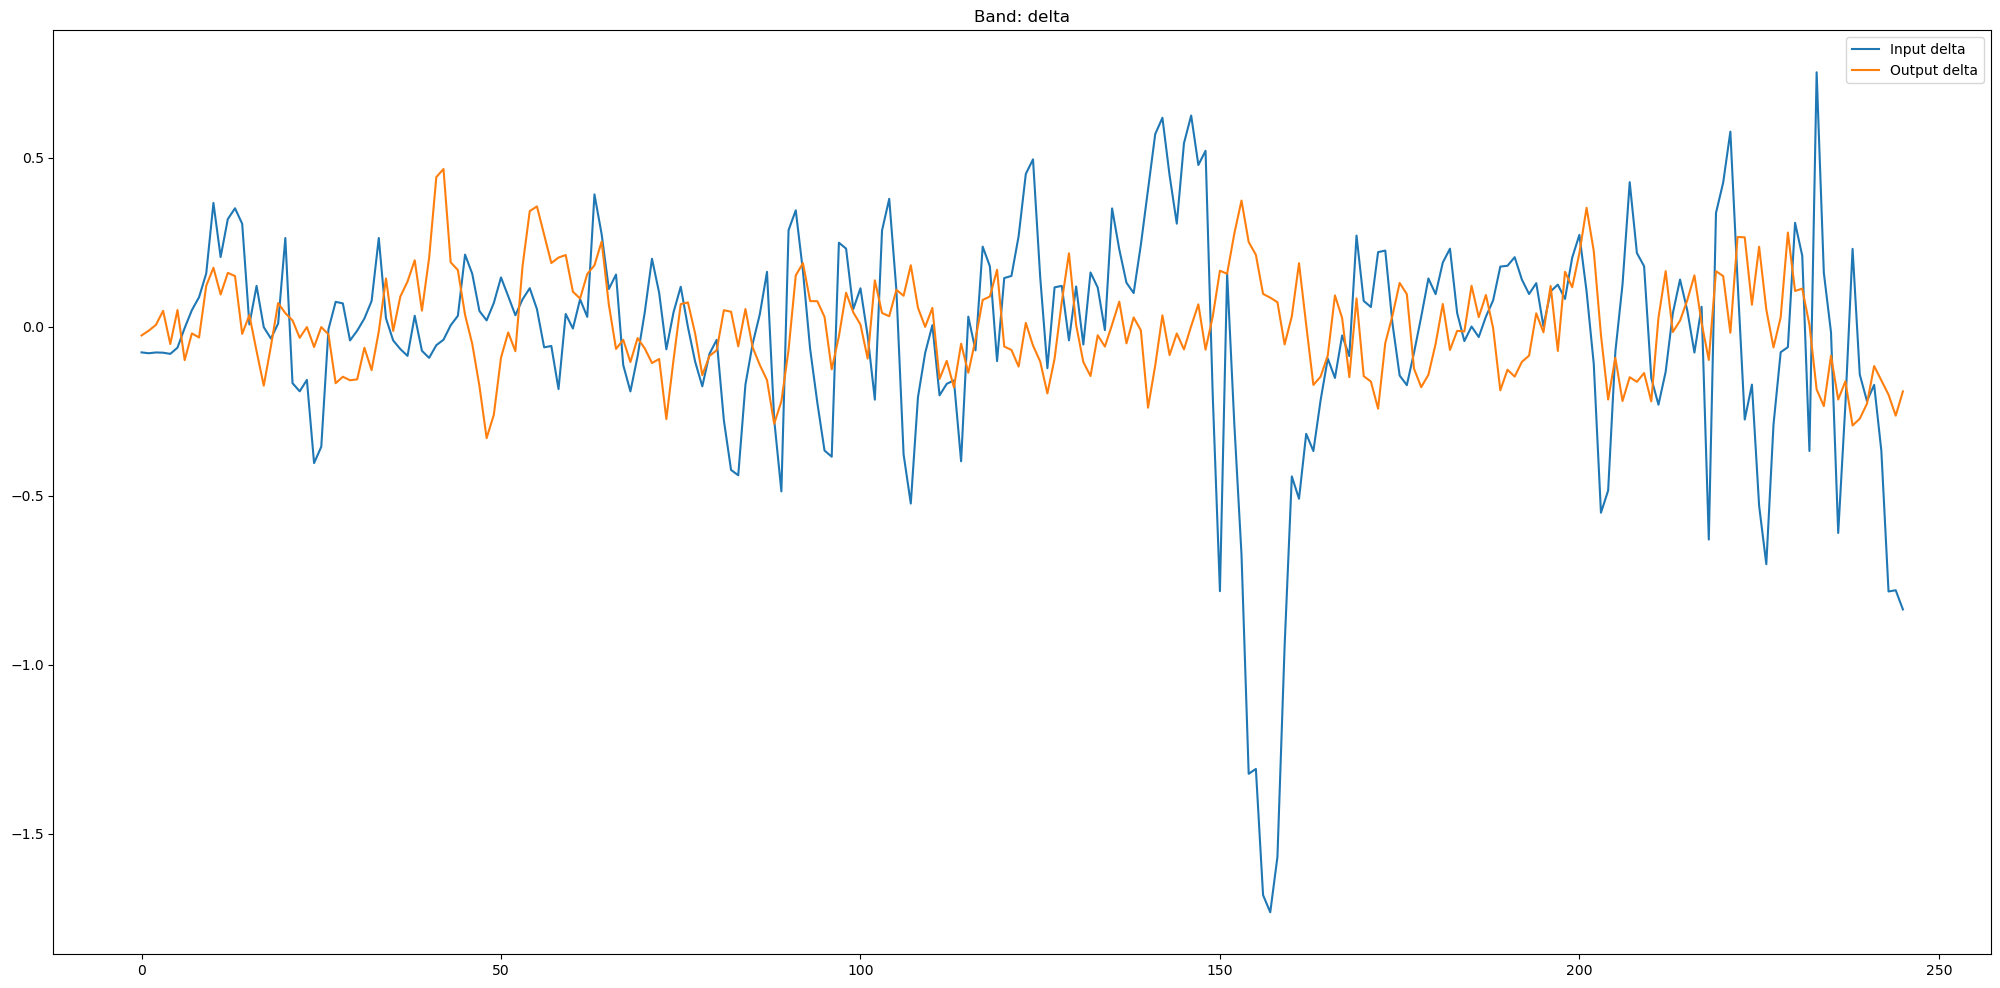

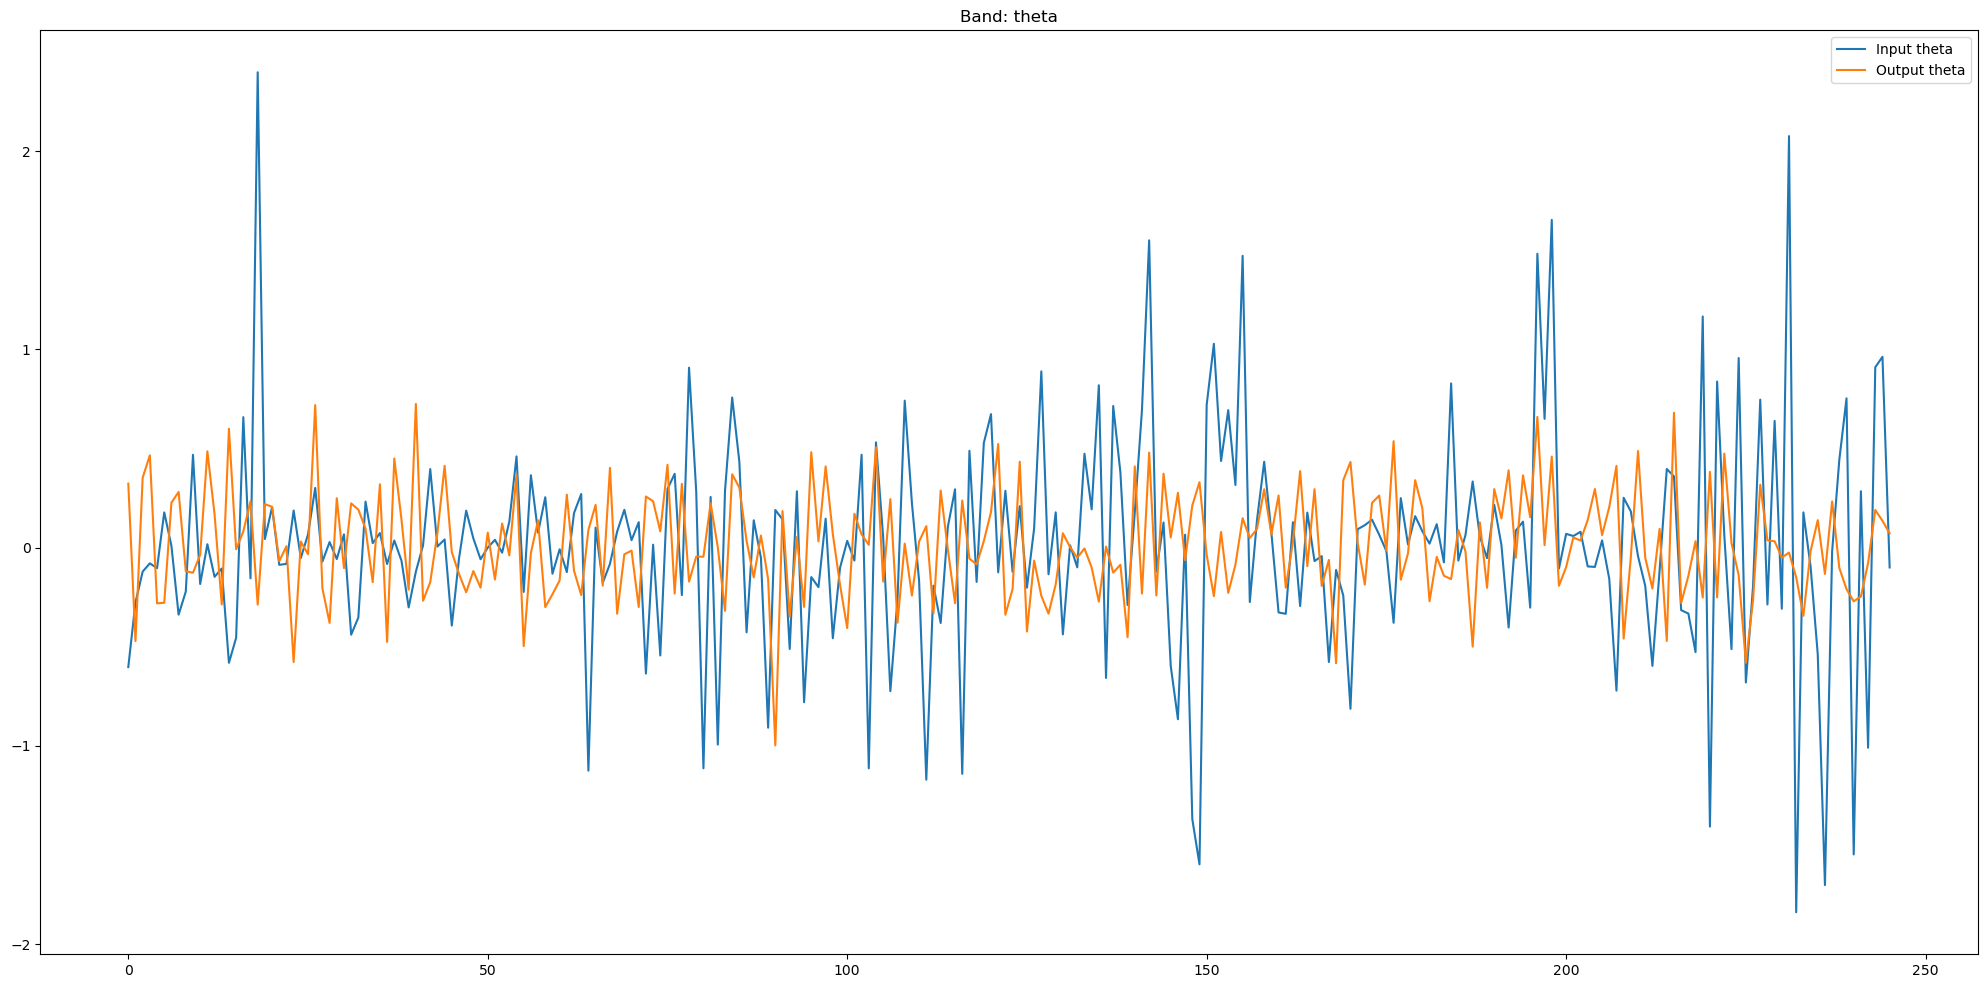

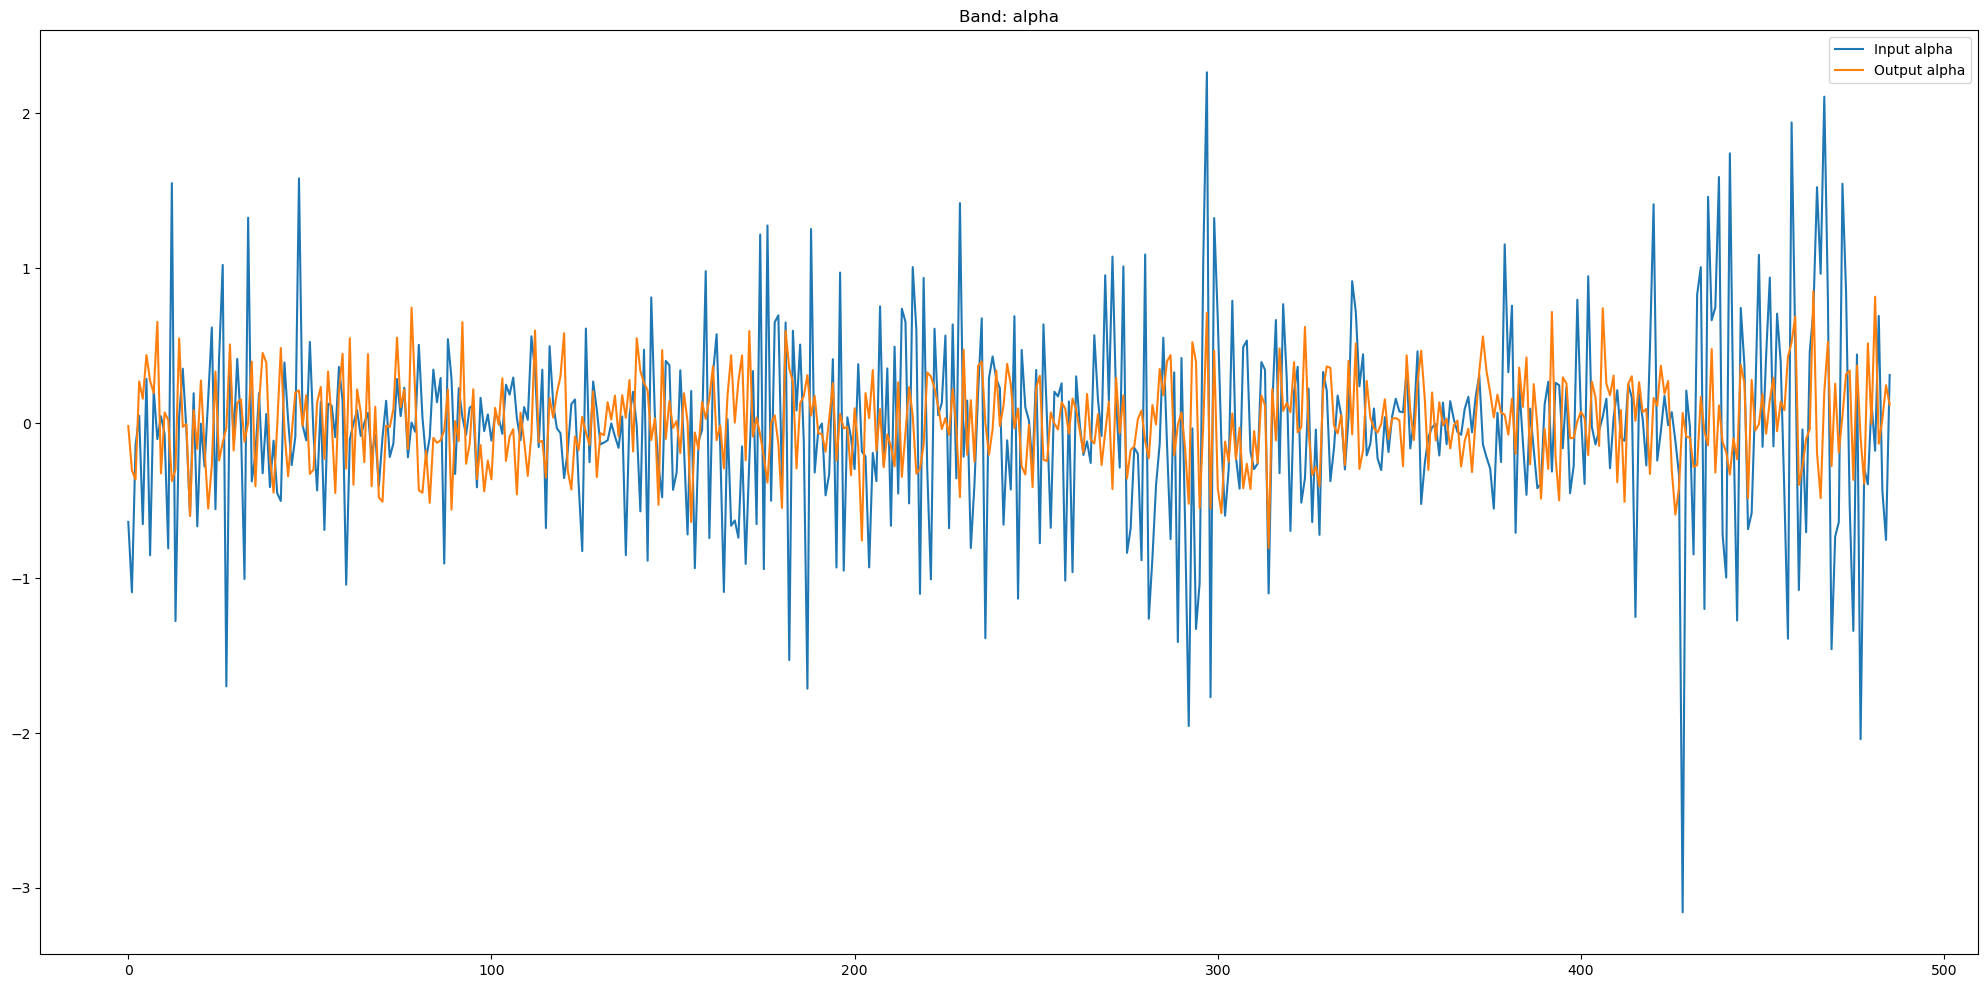

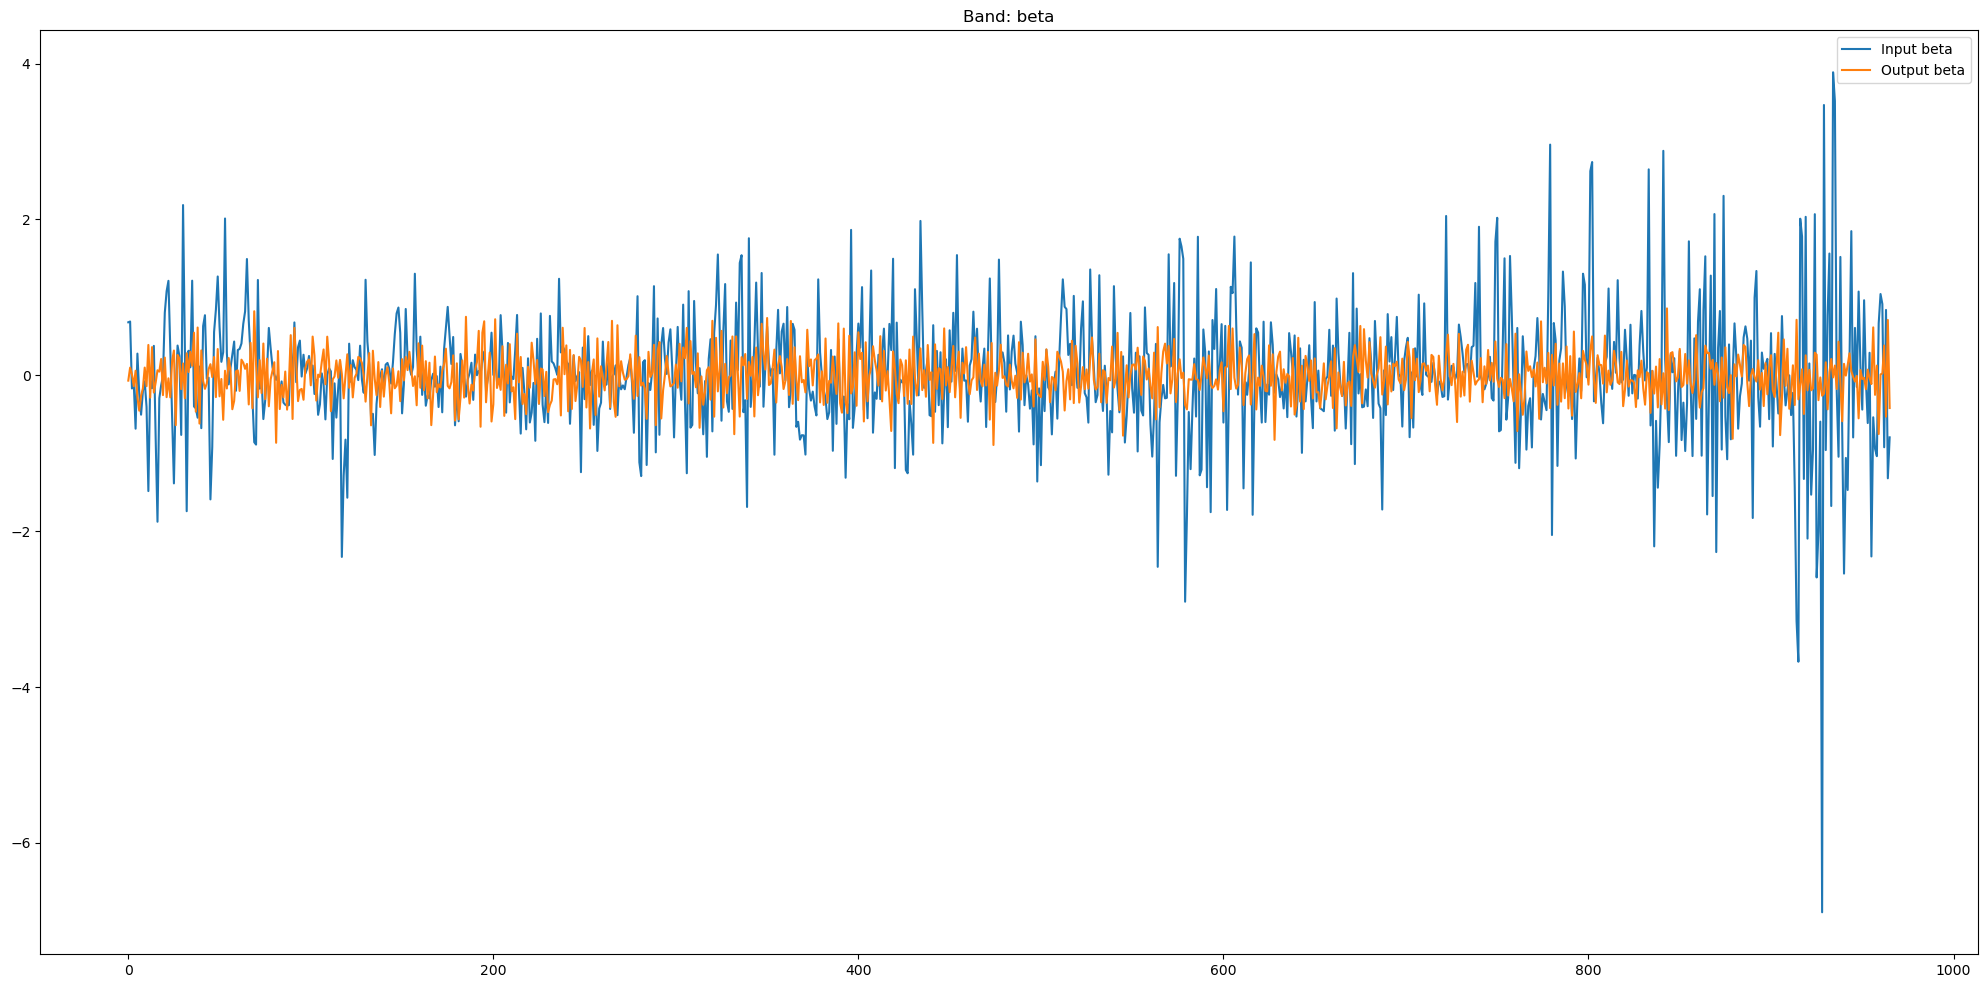

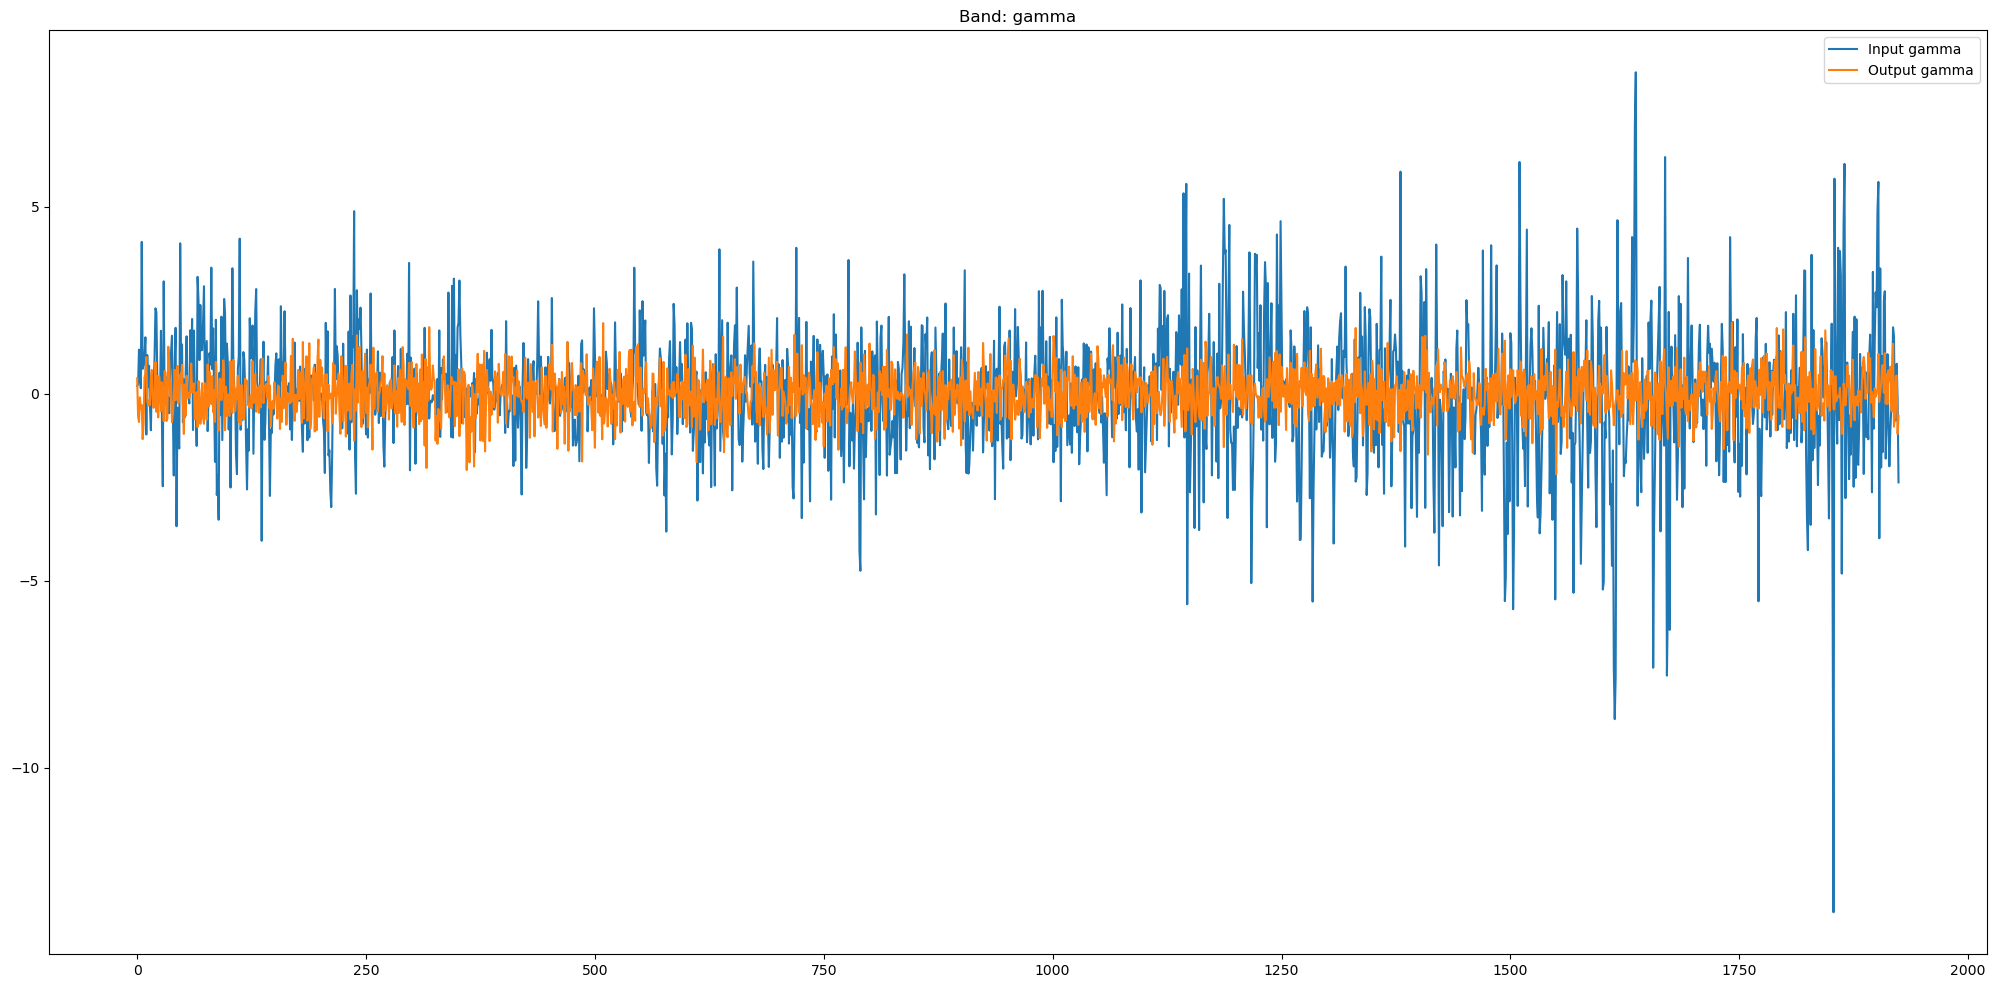

In [16]:
channel = 5
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    plt.plot(inputs[band][9,channel, :].cpu().detach().numpy(), label=f"Input {band}")
    #plt.plot(outputs[band][0][9, channel, :].cpu().detach().numpy(), label=f"Encoding {band}")
    plt.plot(outputs[band][1][9, channel, :].cpu().detach().numpy(), label=f"Output {band}")
    plt.title(f"Band: {band}")
    plt.legend()
    plt.show()

In [20]:
print("*" * 50)
finetune_train_dataset = WaveletFinetuningDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/train")
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_eval_dataset = WaveletFinetuningDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/eval")
print("Dataset Loaded. Length of Validation Dataset: ", len(finetune_eval_dataset))

**************************************************
Loading 2130 folders


100%|██████████| 2130/2130 [01:45<00:00, 20.27it/s]


Dataset Loaded. Length of Train Dataset:  44854
Loading 253 folders


100%|██████████| 253/253 [00:09<00:00, 27.32it/s]


Dataset Loaded. Length of Validation Dataset:  5101


In [34]:
finetune_train_loader = DataLoader(finetune_train_dataset, batch_size=256, num_workers=2, shuffle=True)
finetune_eval_loader = DataLoader(finetune_eval_dataset, batch_size=256, num_workers=2, shuffle=False)
print(len(finetune_train_loader), len(finetune_eval_loader))

176 20


In [36]:
pbar = tqdm.trange(len(finetune_train_loader), desc="Training")
data_iterator = iter(finetune_train_loader)

encoding_outputs = dict()
decoding_outputs = dict()
output_labels = []

for iteration in pbar:
    data = next(data_iterator)
    
    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]

    relevant_bands = [_std_norm(x) for x in relevant_bands]

    inputs = dict(zip(BANDS, relevant_bands))

    with torch.no_grad():
        encoder_outputs = model(data['graph'], inputs)
        output_labels.append(data['graph'].y)
        for band, (encodings, decodings) in encoder_outputs.items():
            if band not in encoding_outputs:
                encoding_outputs[band] = []
            if band not in decoding_outputs:
                decoding_outputs[band] = []
            
            encoding_outputs[band].append(encodings)
            decoding_outputs[band].append(decodings)

Training: 100%|██████████| 176/176 [02:18<00:00,  1.27it/s]


In [37]:
encoding_output_train_all = dict()
for band, encodings in encoding_outputs.items():
    encoding_output_train_all[band] = torch.cat(encodings, dim=0).cpu().numpy()
    print(band, encoding_output_train_all[band].shape)

output_labels_train_all = torch.cat(output_labels, dim=0).cpu().numpy()

delta (44854, 209, 16)
theta (44854, 209, 16)
alpha (44854, 209, 32)
beta (44854, 209, 64)
gamma (44854, 209, 128)


In [39]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA

/usr/local/pace-apps/manual/packages/anaconda3/2023.03/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [43]:
reducer2 = umap.UMAP(n_components=2)

  0%|          | 0/5 [00:00<?, ?it/s]

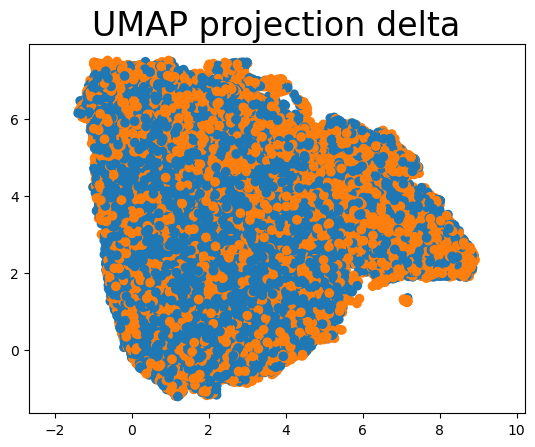

 20%|██        | 1/5 [00:15<01:00, 15.12s/it]

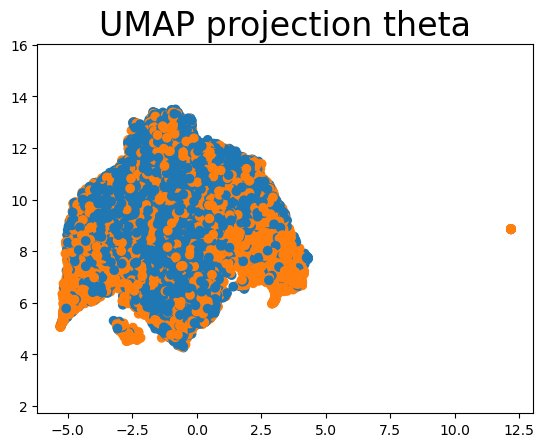

 40%|████      | 2/5 [00:30<00:45, 15.29s/it]

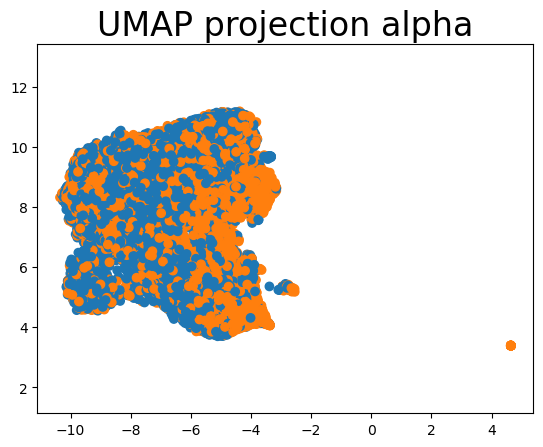

 60%|██████    | 3/5 [01:02<00:45, 22.69s/it]

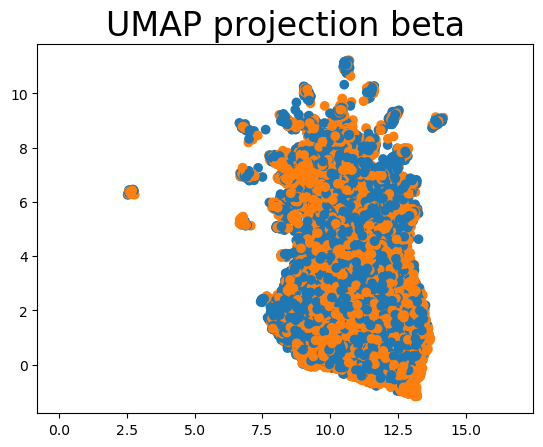

 80%|████████  | 4/5 [01:57<00:35, 35.73s/it]

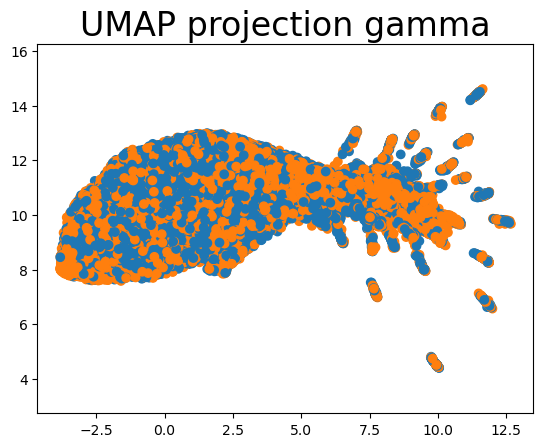

100%|██████████| 5/5 [03:38<00:00, 43.67s/it]


In [55]:
for band in tqdm.tqdm(['delta', 'theta', 'alpha', 'beta', 'gamma']):
    data = encoding_output_train_all[band].reshape(encoding_output_train_all[band].shape[0], -1)
    embeddings = reducer2.fit_transform(data, jobs=-1)
    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=[sns.color_palette()[x] for x in output_labels_train_all])

    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'UMAP projection {band}', fontsize=24)
    plt.show()